<a href="https://colab.research.google.com/github/nehemienakashenyi0-afk/N-H-MIE-NAKASHENYI-/blob/main/analyse_cafe_complet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#TRAVAIL PRATIQUE PERSONNEL 2
#NÉHÉMIE NAKASHENYI
#L2 GÉNIE MINIER


# Analyse et Traitement des Données – Coffee Sales
## Bibliothèques nécessaires

```python
pip install pandas matplotlib
```


In [42]:
import pandas as pd
import matplotlib.pyplot as plt

## Chargement des données

  chargement du fichier CSV contenant les ventes de café.

Le tableau de données est stocké dans la variable (df).

In [43]:
df = pd.read_csv("Coffe_sales.csv")

## Aperçu des données
La base des données  contient plusieurs colonnes comme :
- hour_of_day
- money
- coffee_name
- cash_type
- Weekday
- Month_name

In [44]:
print(df.head())

  hour_of_day cash_type money    coffee_name Time_of_Day Weekday Month_name  \
0          10      card  38,7          Latte     Morning     Fri        Mar   
1          12      card  38,7  Hot Chocolate   Afternoon     Fri        Mar   
2          12      card  38,7  Hot Chocolate   Afternoon     Fri        Mar   
3          13      card  28,9      Americano   Afternoon     Fri        Mar   
4          13      card  38,7          Latte   Afternoon     Fri        Mar   

   Weekdaysort  Monthsort        Date     Time  
0          5.0        3.0  03/01/2024  15:51,5  
1          5.0        3.0  03/01/2024  19:23,5  
2          5.0        3.0  03/01/2024  20:18,1  
3          5.0        3.0  03/01/2024  46:33,0  
4          5.0        3.0  03/01/2024  48:14,6  


# information générale

In [45]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3548 entries, 0 to 3547
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   hour_of_day  3548 non-null   object 
 1   cash_type    3547 non-null   object 
 2   money        3547 non-null   object 
 3   coffee_name  3545 non-null   object 
 4   Time_of_Day  3545 non-null   object 
 5   Weekday      3547 non-null   object 
 6   Month_name   3546 non-null   object 
 7   Weekdaysort  3547 non-null   float64
 8   Monthsort    3547 non-null   float64
 9   Date         3547 non-null   object 
 10  Time         3546 non-null   object 
dtypes: float64(2), object(9)
memory usage: 305.0+ KB
None


## Valeurs manquantes

In [46]:
print(df.isnull().sum())

hour_of_day    0
cash_type      1
money          1
coffee_name    3
Time_of_Day    3
Weekday        1
Month_name     2
Weekdaysort    1
Monthsort      1
Date           1
Time           2
dtype: int64


## Nettoyage des colonnes

In [47]:
df.columns = [c.strip().replace(" ", "_") for c in df.columns]

## Les valeurs statistiques
- moyenne,
- minimum,
- maximum,
- éca.rt-type,
- fréquence

In [48]:
print(df.describe(include='all'))

       hour_of_day cash_type  money          coffee_name Time_of_Day Weekday  \
count         3548      3547   3547                 3545        3545    3547   
unique          18         1     13                    8           3       7   
top             10      card  35,76  Americano with Milk   Afternoon     Tue   
freq           328      3547   1014                  809        1205     572   
mean           NaN       NaN    NaN                  NaN         NaN     NaN   
std            NaN       NaN    NaN                  NaN         NaN     NaN   
min            NaN       NaN    NaN                  NaN         NaN     NaN   
25%            NaN       NaN    NaN                  NaN         NaN     NaN   
50%            NaN       NaN    NaN                  NaN         NaN     NaN   
75%            NaN       NaN    NaN                  NaN         NaN     NaN   
max            NaN       NaN    NaN                  NaN         NaN     NaN   

       Month_name  Weekdaysort    Month

In [49]:
print(df.dtypes)           # Voir le type réel
print(df['hour_of_day'].unique()[:20])  # Voir les valeurs uniques


hour_of_day     object
cash_type       object
money           object
coffee_name     object
Time_of_Day     object
Weekday         object
Month_name      object
Weekdaysort    float64
Monthsort      float64
Date            object
Time            object
dtype: object
['10' '12' '13' '15' '16' '18' '19' '11' '14' '17' '9' '20' '8' '22' '7'
 '21' '6' 'Latte']


In [50]:
df['hour_of_day'] = pd.to_numeric(df['hour_of_day'], errors='coerce')


In [51]:
# Vérification money
print(df['money'].dtype)
print(df['money'].head(10))
print(df['money'].isnull().sum())


object
0    38,7
1    38,7
2    38,7
3    28,9
4    38,7
5    33,8
6    38,7
7    33,8
8    38,7
9    33,8
Name: money, dtype: object
1


## Sélection des colonnes numériques

In [52]:
numeric_cols = df.select_dtypes(include="number").columns



  ##  graphique pour chaque variable numériques

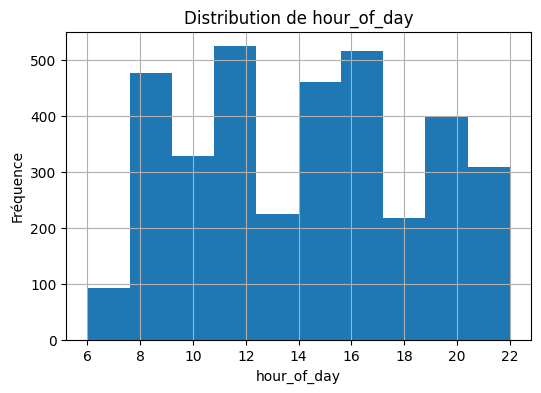

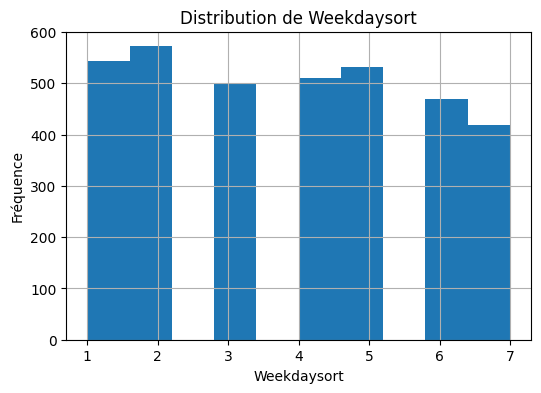

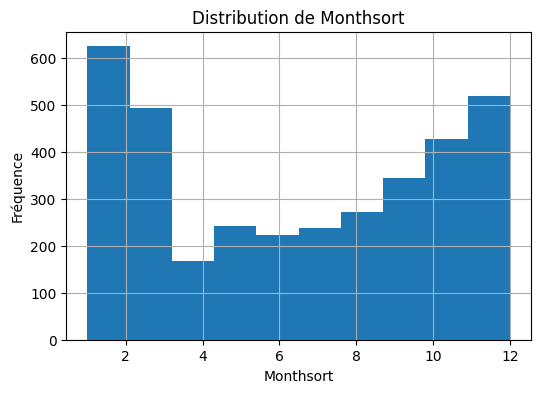

In [53]:
import matplotlib.pyplot as plt

for col in numeric_cols:
    plt.figure(figsize=(6,4))
    df[col].hist()

    plt.title(f"Distribution de {col}")
    plt.xlabel(col)
    plt.ylabel("Fréquence")

                # pour Sauvegarder les graphiques

    plt.savefig(f"{col}.png")
    plt.show()



 ## relations entre les variables numériques

In [54]:
if len(numeric_cols) >= 2:
    corr = df[numeric_cols].corr()
    print(corr)

             hour_of_day  Weekdaysort  Monthsort
hour_of_day     1.000000    -0.002614   0.008293
Weekdaysort    -0.002614     1.000000   0.044141
Monthsort       0.008293     0.044141   1.000000


In [55]:
df['hour_of_day'] = pd.to_numeric(df['hour_of_day'], errors='coerce')



## Conclusion

l'analyse effectuée permet :
- d'explorer les ventes de café,
- d'identifier les distributions des données,
- de vérifier les valeurs manquantes,
- d'étudier les relations entre les variables .